In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visa_df = pd.read_csv("C:\\Users\\prane\\OneDrive\\Documents\\NareshIt\\Data_Files\\Visadataset.csv")

In [3]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [4]:
categorical = visa_df.select_dtypes(include='object').columns
numerical = visa_df.select_dtypes(exclude='object').columns

In [5]:
categorical

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [6]:
numerical

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [7]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [8]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

- there are total 25480 applicants are there

- in that 25480 applicants 17018 applicants got the visa

- 8462 applicants did not get the visa

- also there are 16861 applicants applied for visa from asia

- we want to know how many applicants from asia got certified 

- and how many applicants from asia got denied

In [9]:
# Step 1 : select the continent data
# Step 2 : continent data == 'asia' it is con1
# Step 3 : select the case status data
# Step 4 : case status data == 'certified' is con2
# Step 5 : con = con1&con2
# Step 6 : apply main df on con to get len

In [10]:
con1 = visa_df['continent'] == 'Asia'

In [11]:
con2 = visa_df['case_status'] == 'Certified'

In [12]:
condition = con1&con2

In [13]:
visa_df[condition]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.14,Year,Y,Certified
6,EZYV07,Asia,Bachelor's,N,N,4985,1994,South,53635.39,Year,Y,Certified
8,EZYV09,Asia,Bachelor's,N,N,4810,2012,Midwest,74362.19,Year,Y,Certified
10,EZYV11,Asia,Master's,N,N,2465,2004,Midwest,83588.56,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified


In [14]:
len(visa_df[condition])

11012

In [15]:
con1 = visa_df['continent'] == 'Asia'
con2 = visa_df['case_status'] == 'Certified'
condition = con1&con2
visa_df[condition]
len(visa_df[condition])

11012

In [16]:
con_1 = visa_df['continent'] == 'Asia'
con_2 = visa_df['case_status'] == 'Denied'
condition = con_1&con_2
visa_df[condition]
len(visa_df[condition])

5849

In [17]:
unique_continent = visa_df['continent'].unique()
for i in unique_continent:
    con1 = visa_df['continent'] == i
    con2 = visa_df['case_status'] == 'Certified'
    condition = con1&con2
    visa_df[condition]
    print(i,len(visa_df[condition]))

Asia 11012
Africa 397
North America 2037
Europe 2957
South America 493
Oceania 122


In [18]:
unique_casestatus = sorted(visa_df['case_status'].unique())
unique_casestatus

['Certified', 'Denied']

In [19]:
# dataframe
certified = []
denied = []
for i in unique_continent:
    con1 = visa_df['continent'] == i
    con2 = visa_df['case_status'] == 'Certified'
    con3 = visa_df['case_status'] == 'Denied'
    Certified_Condition = con1&con2
    Denied_Condition = con1&con3
    certified.append(len(visa_df[Certified_Condition]))
    denied.append(len(visa_df[Denied_Condition]))

pd.DataFrame(zip(certified,denied),index=unique_continent,columns=unique_casestatus)

,Certified,Denied
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


**we have another shortcut called cross tab**

In [20]:
pd.crosstab(index=visa_df['continent'],columns=visa_df['case_status'])

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [21]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
# pd.crosstab(<index>,<columns>)
r1 = pd.crosstab(col1,col2)

<Axes: xlabel='continent'>

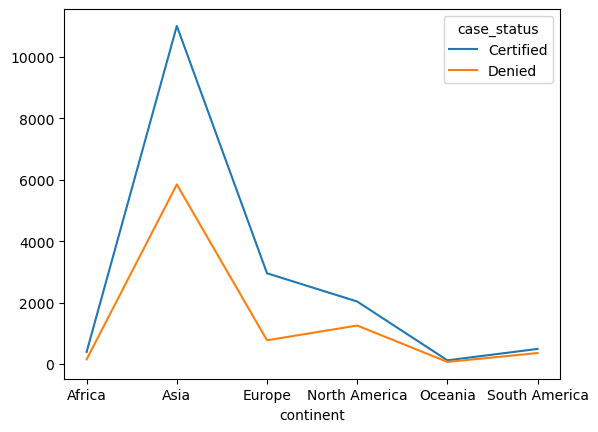

In [22]:
r1.plot()

<Axes: xlabel='continent'>

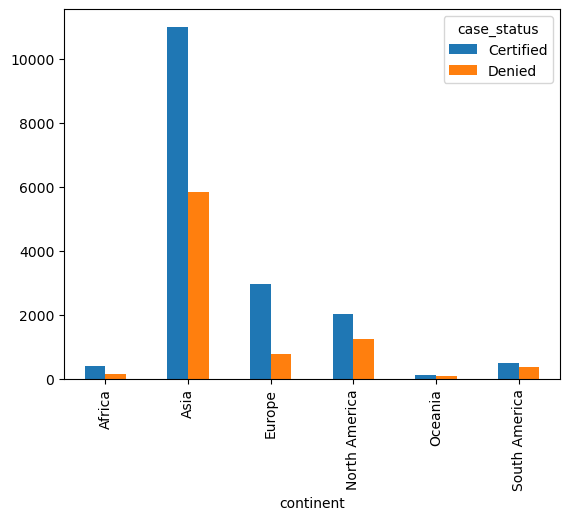

In [23]:
r1.plot(kind='bar')

**case status - continent - education_of_employee**

- from asia there are 16k applicants applied for visa

    - in that 11k+ ppl got certified

        - in that 11k ppl different education applicants are avaliable

- we want those information

In [24]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
col3 = visa_df['education_of_employee']
cols = [col1,col3]
pd.crosstab(col2,cols)

continent                 Africa                                      Asia  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
case_status                                                                  
Certified                     81        43          23      250       4407   
Denied                        62        11          43       38       2761   

continent                                                Europe            \
education_of_employee Doctorate High School Master's Bachelor's Doctorate   
case_status                                                                 
Certified                   780         676     5149       1040       788   
Denied                      143        1614     1331        259        58   

continent              ... North America             Oceania            \
education_of_employee  ...   High School Master's Bachelor's Doctorate   
case_status            ...                                               
Certified              ...           210      979         38        19   
Denied                 ...           191      429         28         3   

continent                                  South America            \
education_of_employee High School Master's    Bachelor's Doctorate   
case_status                                                          
Certified                      19       46           160        75   
Denied                         17       22           173        14   

continent                                   
education_of_employee High School Master's  
case_status                                 
Certified                      74      184  
Denied                         63      109  

[2 rows x 24 columns]

In [25]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
col3 = visa_df['education_of_employee']
cols = [col1,col2]
pd.crosstab(col3,cols)

continent                Africa             Asia           Europe         \
case_status           Certified Denied Certified Denied Certified Denied   
education_of_employee                                                      
Bachelor's                   81     62      4407   2761      1040    259   
Doctorate                    43     11       780    143       788     58   
High School                  23     43       676   1614       162    328   
Master's                    250     38      5149   1331       967    130   

continent             North America          Oceania        South America  \
case_status               Certified Denied Certified Denied     Certified   
education_of_employee                                                       
Bachelor's                      641    584        38     28           160   
Doctorate                       207     51        19      3            75   
High School                     210    191        19     17            74   
Master's                        979    429        46     22           184   

continent                     
case_status           Denied  
education_of_employee         
Bachelor's               173  
Doctorate                 14  
High School               63  
Master's                 109

In [26]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
col3 = visa_df['education_of_employee']
cols = [col2,col3]
r2 = pd.crosstab(col1,cols)

In [27]:
r2

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

<Axes: xlabel='continent'>

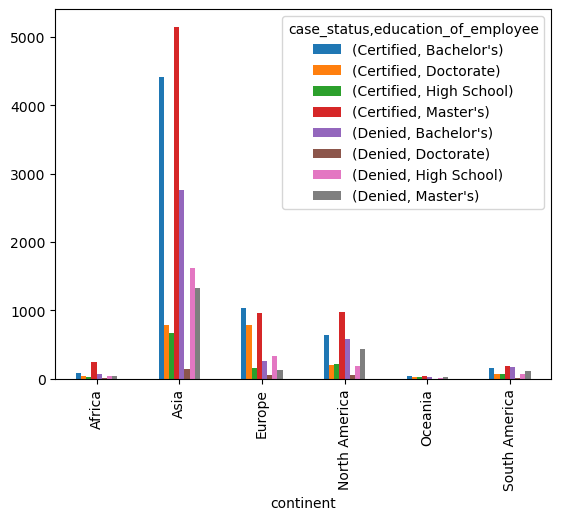

In [28]:
r2.plot(kind='bar')

**group by**

In [29]:
visa_df['education_of_employee'].value_counts()

education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

In [30]:
list(visa_df.groupby('education_of_employee'))

[("Bachelor's",
           case_id      continent education_of_employee has_job_experience  \
  2         EZYV03           Asia            Bachelor's                  N   
  3         EZYV04           Asia            Bachelor's                  N   
  6         EZYV07           Asia            Bachelor's                  N   
  7         EZYV08  North America            Bachelor's                  Y   
  8         EZYV09           Asia            Bachelor's                  N   
  ...          ...            ...                   ...                ...   
  25466  EZYV25467         Europe            Bachelor's                  Y   
  25468  EZYV25469           Asia            Bachelor's                  N   
  25473  EZYV25474           Asia            Bachelor's                  Y   
  25475  EZYV25476           Asia            Bachelor's                  Y   
  25479  EZYV25480           Asia            Bachelor's                  Y   
  
        requires_job_training  no_of_employee

In [31]:
visa_df.groupby('education_of_employee').count()

,case_id,continent,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
education_of_employee,,,,,,,,,,,
Bachelor's,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234
Doctorate,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192
High School,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420
Master's,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634


In [32]:
visa_df.groupby('education_of_employee').size()

education_of_employee
Bachelor's     10234
Doctorate       2192
High School     3420
Master's        9634
dtype: int64

In [33]:
# based on group by select an another column
visa_df.groupby('education_of_employee')['prevailing_wage']

In [34]:
visa_df['prevailing_wage'].mean() # it is the mean of all 25480 observations

np.float64(74455.81459209183)

In [35]:
visa_df[visa_df['education_of_employee'] == "Bachelor's"]['prevailing_wage'].mean()

np.float64(73405.44373547)

In [36]:
visa_df.groupby('education_of_employee')['prevailing_wage'].mean()

education_of_employee
Bachelor's     73405.443735
Doctorate      64561.076657
High School    71582.147756
Master's       78843.057843
Name: prevailing_wage, dtype: float64

In [37]:
con = visa_df['case_status'] == 'Certified'
new_df = visa_df[con]
new_df.groupby('continent').size()

continent
Africa             397
Asia             11012
Europe            2957
North America     2037
Oceania            122
South America      493
dtype: int64

In [38]:
visa_df[visa_df['continent'] == 'Asia']['prevailing_wage'].min()

3.3188

In [39]:
visa_df.groupby('continent')['prevailing_wage'].min()

continent
Africa           32.9286
Asia              3.3188
Europe            9.1753
North America     2.1367
Oceania          24.4888
South America     3.0031
Name: prevailing_wage, dtype: float64

- we have seen **continent and case status**

- we have seen 3 varaibles **continent,case status and Education of Employee**

- we also done similar analysis using group by

- only categorical column analysis completed

- only numerical column analysis completed

- Also bivariate and multivariate analysis completed

- now we need to perform two numerical column analysis

    - this will give relation between two columns which aree numerical in nature

    - so we can perform **correlation matrix** to get relationship

    - also we need to perform **scatter plots** to visualize the relation

In [40]:
categorical

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [41]:
numerical

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

**plt.scatter()**

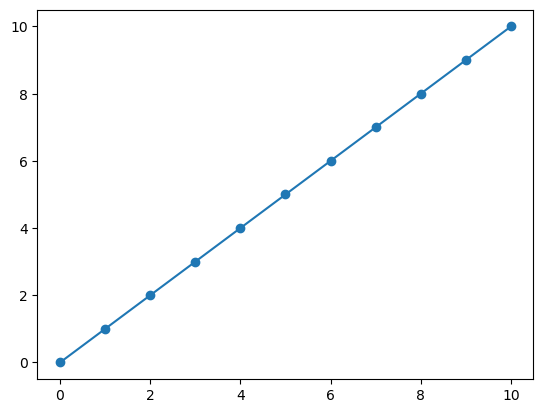

In [43]:
x = range(0,11)
y = range(0,11)
plt.scatter(x,y)
plt.plot(x,y)

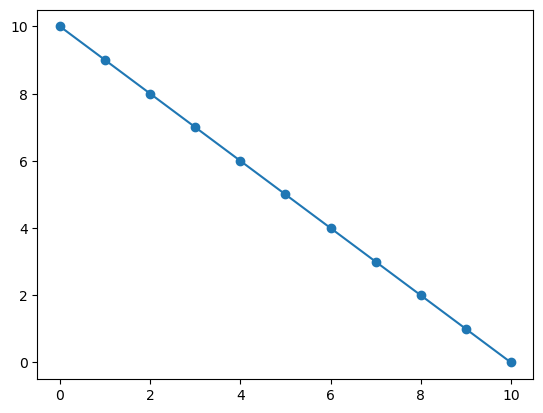

In [46]:
x = range(0,11)
y = range(10,-1,-1)
plt.scatter(x,y)
plt.plot(x,y)

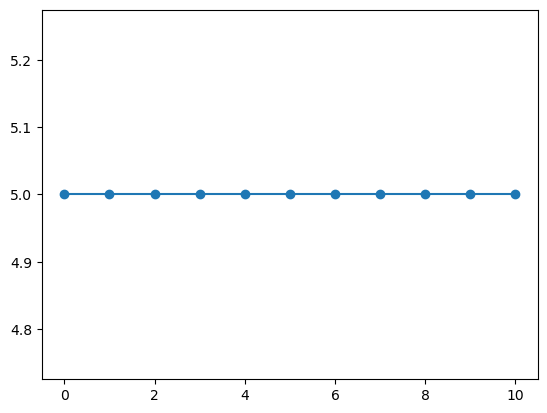

In [53]:
x = range(0,11)
y = [5 for i in range(0,11)]
plt.scatter(x,y)
plt.plot(x,y)

In [55]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


In [57]:
col1 = visa_df['no_of_employees']
col2 = visa_df['yr_of_estab']
col3 = visa_df['prevailing_wage']

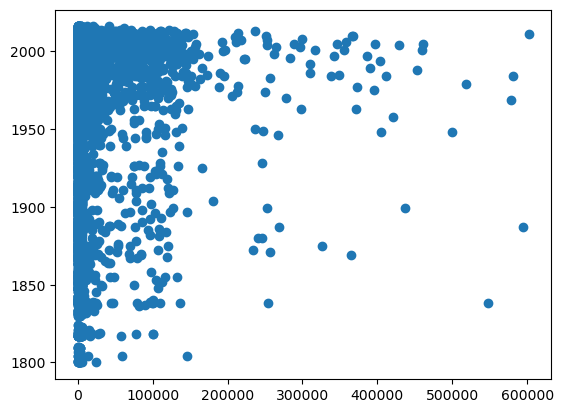

In [61]:
plt.scatter(col1,col2)

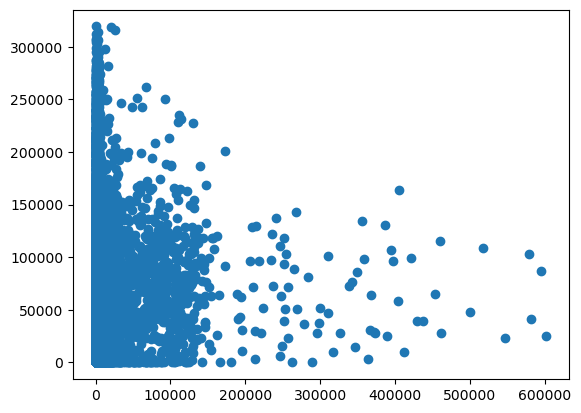

In [62]:
plt.scatter(col1,col3)

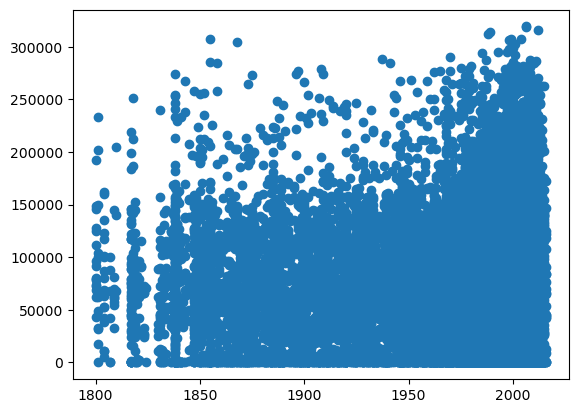

In [63]:
plt.scatter(col2,col3)

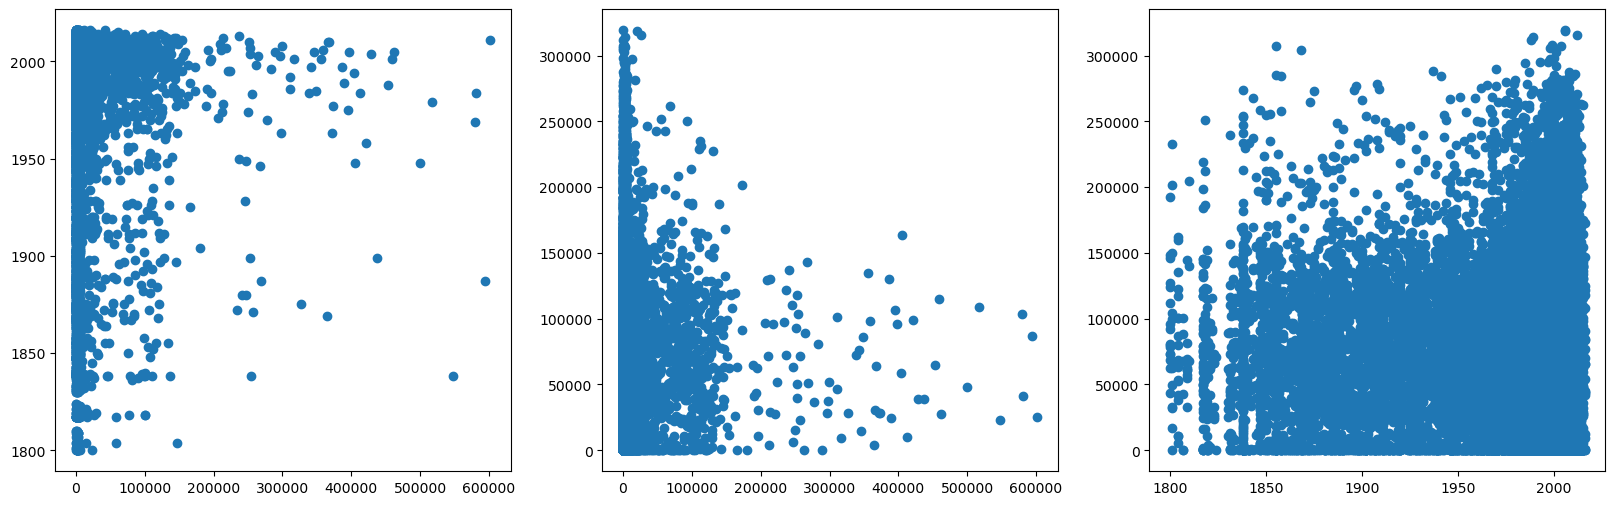

In [69]:
plt.figure(figsize=((20,6)))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col1,col3)
plt.subplot(1,3,3).scatter(col2,col3)

In [70]:
wine_quality = pd.read_csv(r"C:\Users\prane\OneDrive\Documents\NareshIt\Data_Files\winequality_red.csv")

In [74]:
cat_data = wine_quality.select_dtypes(include='object').columns
num_data = wine_quality.select_dtypes(exclude='object').columns

In [75]:
num_data

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [80]:
wine_quality.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


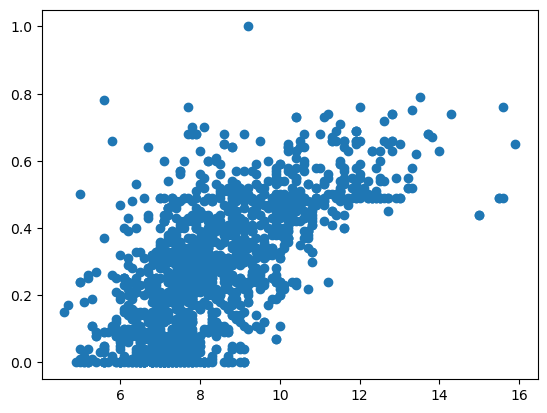

In [81]:
col_1 = wine_quality['fixed acidity']
col_2 = wine_quality['citric acid']
plt.scatter(col_1,col_2)

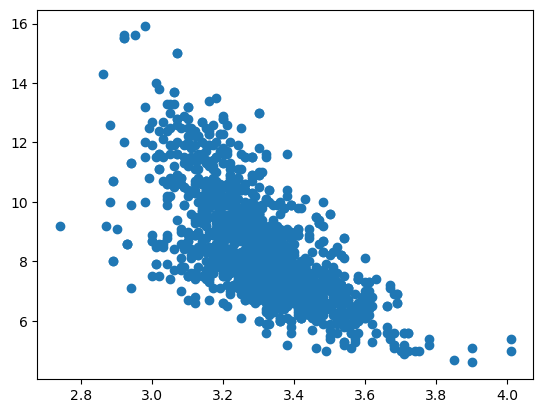

In [82]:
col_3 = wine_quality['pH']
plt.scatter(col_3,col_1)

**Heat map**

- any matrix values we can visualize using a heat map

- heat map will provide colours for different values

- heat map also provides colours bar which indicates the colour and its value

- for example the values ranges from 0.8 to 1 display as **blue colour**

- so we no need to check values , we can directly see the blue colour

- so immediately we can see blue colour means highest values which is 0.8 to 1

- heat map is avaliable in **seaborn** module

<Axes: >

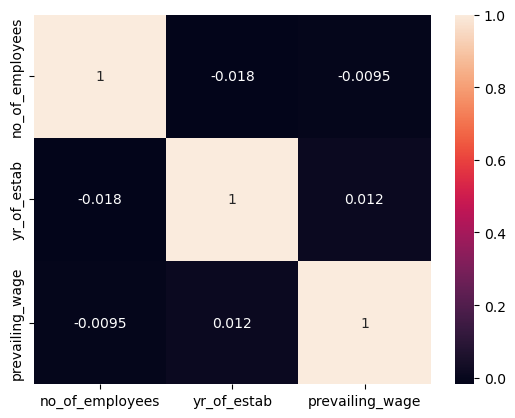

In [86]:
visa_corr = visa_df.corr(numeric_only=True)
sns.heatmap(visa_corr,annot=True)

<Axes: >

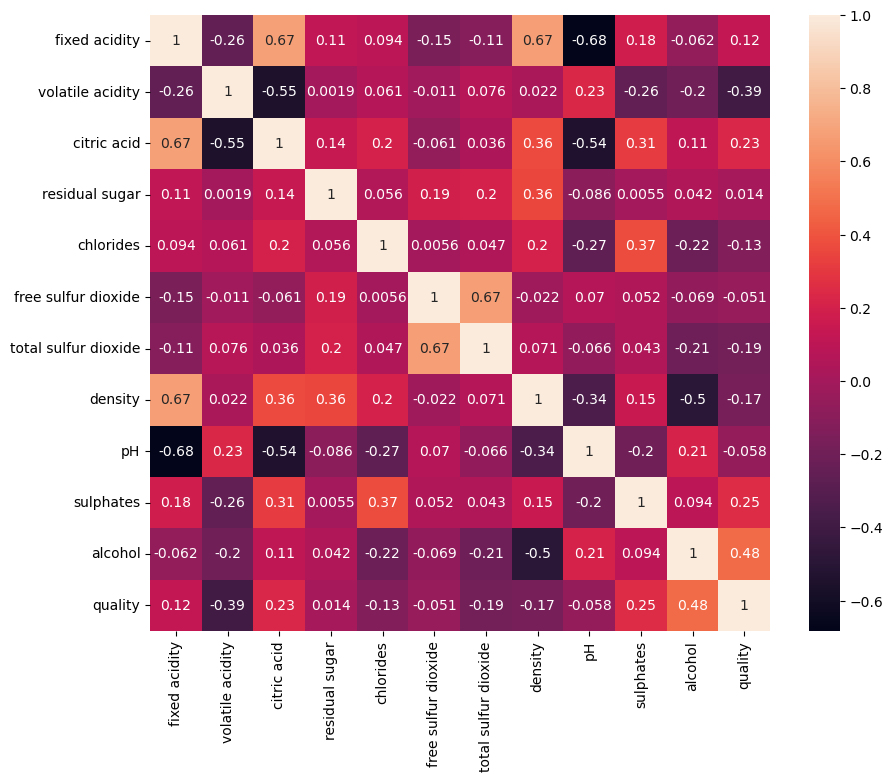

In [88]:
wine_corr = wine_quality.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(wine_corr,annot=True)

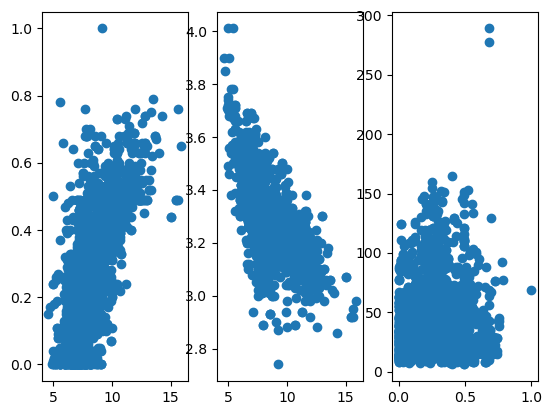

In [90]:
col_1 = wine_quality['fixed acidity']
col_2 = wine_quality['citric acid']
col_3 = wine_quality['pH']
col_4 = wine_quality['total sulfur dioxide']
plt.subplot(1,3,1).scatter(col_1,col_2)
plt.subplot(1,3,2).scatter(col_1,col_3)
plt.subplot(1,3,3).scatter(col_2,col_4)